# Distribution of Maximum Non-Zero Distances
Normalization may impact the distance scaling function. To see if this effect is expected to be large, we'll plot the distribution of the maximum distance at which a non-zero contact is observed.

## Imports

In [6]:
# Imports
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import hic_mask_threshold, import_cool_dir, fetch_region

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

In [7]:
### Importing data ###
clrs = import_cool_dir(sc_dir)
chr1s = []
for clr in clrs:
    chr1s.append(fetch_region(clr, "chr1"))

## Helper Functions

In [8]:
def nonzero_max_dist(map: np.ndarray, threshold: float=0, type: str="raw"):
    '''
        Give the number of maximum diagonal at which a nonzero
        contact was detected.

        Parameters
        ----------
        map : np.ndarray
            Symmetrical contact map
        threshold : float
            Threshold to use for masking.
            Default = 0
        type : str
            Type of threshold to use for masking.
            Default = "raw".
        
        Returns
        -------
        max_d : int
            Maximum diagonal with nonzero contacts.
    '''
    # Extracting coordinates
    coords = hic_mask_threshold(map, cut_off=threshold, type=type)[1]

    # Extracting diagonal
    dists = []
    for coord in coords:
        dists.append(np.abs(coord[0]-coord[1]))
    max_d = max(dists)

    return max_d

## Raw data

In [9]:
### Collecting data ###
dists = []
for chr1 in chr1s:
    dists.append(nonzero_max_dist(chr1))

Text(0, 0.5, 'Counts')

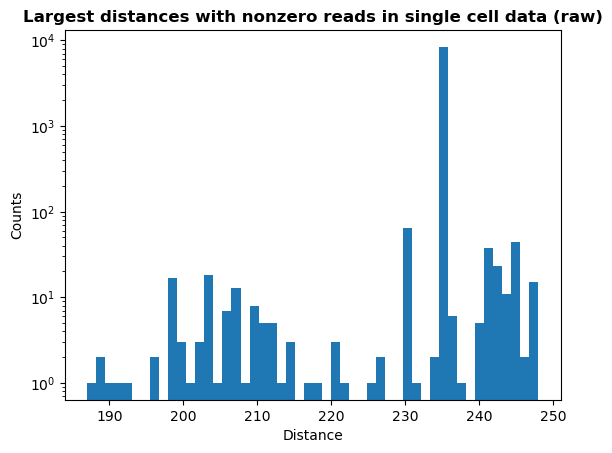

In [16]:
### Graphing ###
plt.hist(dists, bins=50, log=True)
plt.title("Largest distances with nonzero reads in single cell data (raw)", fontweight="bold")
plt.xlabel("Distance")
plt.ylabel("Counts")

## Tresholding at 90%

In [17]:
### Collecting data ###
dists = []
for chr1 in chr1s:
    dists.append(nonzero_max_dist(chr1, 90, "percentile"))

Text(0, 0.5, 'Counts')

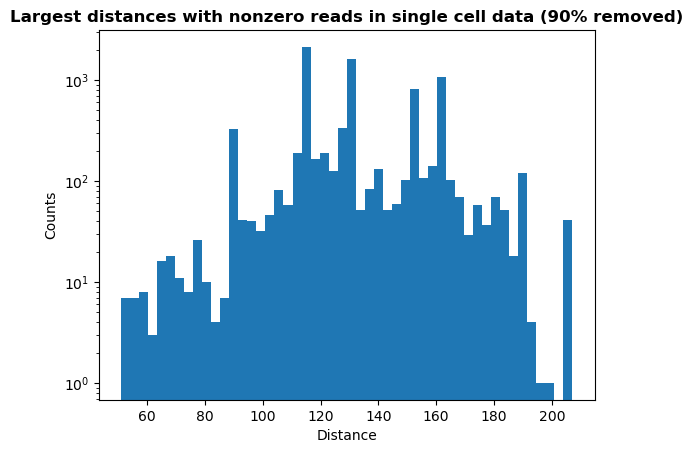

In [18]:
### Graphing ###
plt.hist(dists, bins=50, log=True)
plt.title("Largest distances with nonzero reads in single cell data (90% removed)", fontweight="bold")
plt.xlabel("Distance")
plt.ylabel("Counts")